<a href="https://colab.research.google.com/github/Jayesh2422/ML_LAB/blob/main/ETE%20exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [16]:
df = pd.read_csv('/content/Mall_Customers.csv')

In [17]:
print("First 5 rows:")
print(df.head())

First 5 rows:
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [18]:
df.columns = df.columns.str.strip().str.replace(' ', '_')
print("Cleaned Columns:", df.columns.tolist())

Cleaned Columns: ['CustomerID', 'Genre', 'Age', 'Annual_Income_(k$)', 'Spending_Score_(1-100)']


In [19]:
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

In [20]:
if 'Gender' in df.columns:
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])
else:
    print("⚠️ Gender column not found, skipping encoding.")

⚠️ Gender column not found, skipping encoding.


In [21]:
df = df.select_dtypes(include=[np.number])

In [22]:
X = df.values


In [23]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [24]:
plt.figure(figsize=(10,5))
linked = linkage(X_scaled, method='ward')

<Figure size 1000x500 with 0 Axes>

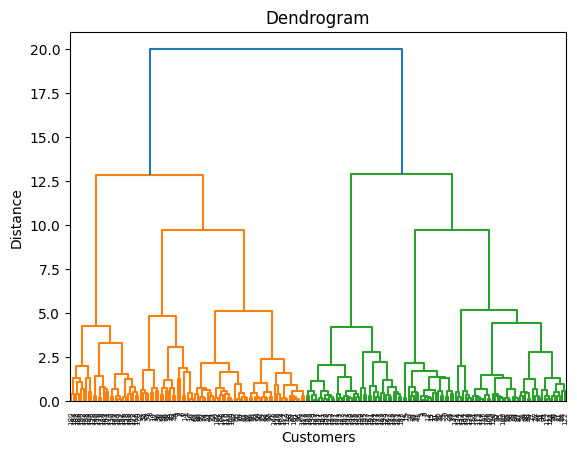

In [25]:
dendrogram(linked)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Distance')
plt.show()

In [26]:
model = AgglomerativeClustering(n_clusters=5, linkage='ward')
labels = model.fit_predict(X_scaled)

In [27]:
df['Cluster'] = labels

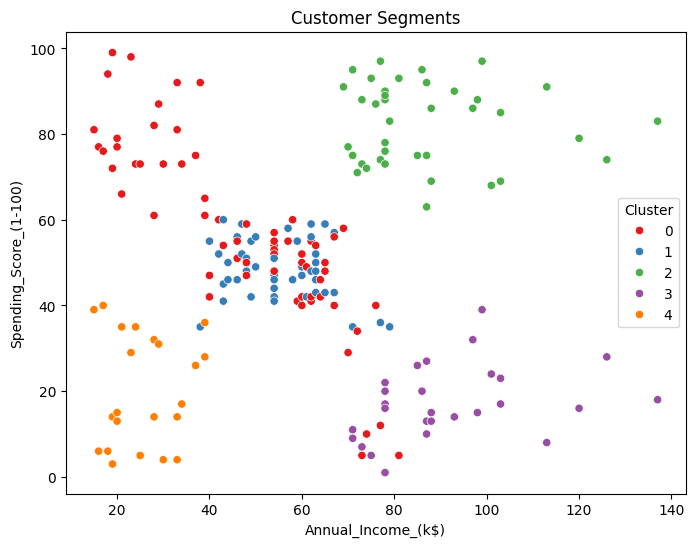

In [28]:
income_col = None
spending_col = None

for col in df.columns:
    if 'Income' in col:
        income_col = col
    if 'Spending' in col:
        spending_col = col

if income_col and spending_col:
    plt.figure(figsize=(8,6))
    sns.scatterplot(
        x=df[income_col],
        y=df[spending_col],
        hue=df['Cluster'],
        palette='Set1'
    )
    plt.title('Customer Segments')
    plt.show()
else:
    print("⚠️ Income/Spending columns not found for visualization")

In [29]:
score = silhouette_score(X_scaled, labels)
print("Silhouette Score:", round(score, 3))

Silhouette Score: 0.39
